# 混同行列分析ノートブック
感受性推論AIを用いたタイル単位・ケース単位の混同行列作成・可視化・保存

---

## 概要
001_画像から感受性推論AIヒートマップ_case_median_ensemble.pyのアルゴリズムを使用し、以下を実行：
- タイル（単画像）レベルの混同行列と評価指標（Accuracy, Sensitivity, Specificity, Precision）
- ケース（サブサブフォルダー）レベルの混同行列と評価指標
- 各指標の95%信頼区間を計算
- 混同行列をヒートマップで可視化
- 結果を .png および .xlsx で保存

## 1. 必要環境のインストールとインポート

In [1]:
import subprocess
import sys

# 必要なパッケージをインストール
packages = [
    'numpy', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn',
    'openpyxl', 'statsmodels', 'tqdm', 'Pillow'
]

for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

Installing scikit-learn...
Installing Pillow...


In [2]:
import importlib.util
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from statsmodels.stats.proportion import proportion_confint
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 日本語フォント設定
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
print("✓ すべてのパッケージが準備完了")

✓ すべてのパッケージが準備完了


## 2. baseモジュールとモデルの読み込み

In [3]:
# baseモジュールを読み込み（001スクリプトと同じ方法）
base_path = Path("/home/tatsushi/デスクトップ/chemosensitivity_gastric_cancer/002_画像から感受性推論AIヒートマップ_tile_level_ensemble.py")

def load_base_module():
    spec = importlib.util.spec_from_file_location("dual_ensemble_base", base_path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Failed to load base module: {base_path}")
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

print("Loading base module...")
base = load_base_module()
print(f"✓ Base module loaded from {base_path}")

Loading base module...
✓ Base module loaded from /home/tatsushi/デスクトップ/chemosensitivity_gastric_cancer/002_画像から感受性推論AIヒートマップ_tile_level_ensemble.py


In [4]:
print("Loading models...")
print("Loading ViT backend...")
vit_backend = base.load_backend(base.VIT_SPEC, base.DEVICE)
print("Loading EVA02 backend...")
eva_backend = base.load_backend(base.EVA02_SPEC, base.DEVICE)

# モデル情報の表示
print("\n" + "="*60)
print("MODEL INFORMATION")
print("="*60)
for backend_name, backend in [("ViT", vit_backend), ("EVA02", eva_backend)]:
    spec = backend["spec"]
    input_dim = backend["models"][0].net[0].in_features
    print(f"\n[{backend_name}]")
    print(f"  feature     : {spec.feature_model_name}")
    print(f"  img_size    : {spec.img_size}x{spec.img_size}")
    print(f"  pooling     : {spec.pooling}")
    print(f"  n_models    : {len(backend['models'])}")
    print(f"  input_dim   : {input_dim}")
    print(f"  cutoff      : {backend['cutoff']:.4f}")
    print(f"  weight      : {spec.weight:.3f}")

print(f"\nDevice: {base.DEVICE}")
print("="*60)

Loading models...
Loading ViT backend...


Loading EVA02 backend...

MODEL INFORMATION

[ViT]
  feature     : vit_large_patch16_384.augreg_in21k_ft_in1k
  img_size    : 560x560
  pooling     : cls
  n_models    : 5
  input_dim   : 1024
  cutoff      : 0.4500
  weight      : 0.500

[EVA02]
  feature     : eva02_large_patch14_448.mim_in22k_ft_in22k
  img_size    : 560x560
  pooling     : avg_patch_tokens
  n_models    : 5
  input_dim   : 1024
  cutoff      : 0.4000
  weight      : 0.500

Device: cuda


## 3. 画像ファイル収集と正解ラベルの割当

In [5]:
# 対象フォルダの設定
root_path = Path("/home/tatsushi/デスクトップ/sensitivity_data7/image-sens/mucosa/2026_hakuho")

# ラベルマッピング
label_mapping = {
    '0_sens': 0,      # Sensitive
    '2_resis': 2      # Resistant
}

print(f"Collecting images from: {root_path}")
print(f"Label mapping: {label_mapping}\n")

# 画像ファイルを収集
image_records = []

for class_folder in ['0_sens', '2_resis']:
    class_path = root_path / class_folder
    if not class_path.exists():
        print(f"⚠ Warning: {class_path} does not exist")
        continue
    
    # サブサブフォルダー（症例）を走査
    for case_folder in class_path.iterdir():
        if not case_folder.is_dir():
            continue
        
        case_id = case_folder.name
        label = label_mapping[class_folder]
        
        # .jpg と .JPG ファイルを収集
        for img_path in list(case_folder.glob('*.jpg')) + list(case_folder.glob('*.JPG')):
            image_records.append({
                'image_path': img_path,
                'true_label': label,
                'case_id': case_id,
                'class_folder': class_folder
            })

# DataFrame に変換
df_images = pd.DataFrame(image_records)
print(f"✓ Collected {len(df_images)} images")
print(f"\nImage distribution:")
print(df_images.groupby(['class_folder', 'case_id']).size().head(10))
print(f"\nTotal cases: {df_images['case_id'].nunique()}")

Label mapping: {'0_sens': 0, '2_resis': 2}

✓ Collected 790 images

Image distribution:
class_folder  case_id              
0_sens        605_1-hirose_bio          8
              605_2-hirose_surg        95
              618_1-yoshihama_bio      17
              623_1-watanabe_bio       27
2_resis       601_1-tomonaga_bio        5
              602_1-yamashita_bio      40
              603_1-kubo_bio            8
              604_1-takimoto_bio       19
              606_1-arai_bio           10
              607_1-nakabayashi_bio    15
dtype: int64

Total cases: 53


## 4. タイル（単画像）単位での推論（ViT + EVA02）

In [6]:
print("\n" + "="*60)
print("TILE-LEVEL INFERENCE")
print("="*60)

tile_results = []

for idx, row in tqdm(df_images.iterrows(), total=len(df_images), desc="Processing images"):
    try:
        # 画像を読み込み
        img = Image.open(row['image_path']).convert('RGB')
        cropped_img = base.center_crop_max_square(img)
        
        # ViT推論
        vit_prob, vit_margin, _ = base.predict_with_backend(vit_backend, cropped_img)
        vit_label, vit_class = base.prob_margin_to_class(vit_margin)
        
        # EVA02推論
        eva_prob, eva_margin, _ = base.predict_with_backend(eva_backend, cropped_img)
        eva_label, eva_class = base.prob_margin_to_class(eva_margin)
        
        # 最終判定（001と同じ combine_predictions を使用）
        final_prob, final_margin = base.combine_predictions(
            vit_prob, vit_margin, eva_prob, eva_margin
        )
        final_label, final_class = base.prob_margin_to_class(final_margin)
        final_label = 0 if final_class == '0_sens' else 2
        
        tile_results.append({
            'image_path': row['image_path'],
            'case_id': row['case_id'],
            'true_label': row['true_label'],
            'true_class': 'sens' if row['true_label'] == 0 else 'resis',
            'vit_prob': vit_prob,
            'vit_margin': vit_margin,
            'vit_label': vit_label,
            'vit_class': vit_class,
            'eva_prob': eva_prob,
            'eva_margin': eva_margin,
            'eva_label': eva_label,
            'eva_class': eva_class,
            'final_prob': final_prob,
            'final_margin': final_margin,
            'final_label': final_label,
            'final_class': final_class,
        })
        
    except Exception as e:
        print(f"\n⚠ Error processing {row['image_path'].name}: {e}")
        continue

# DataFrame に変換
df_tiles = pd.DataFrame(tile_results)
print(f"\n✓ Inference completed for {len(df_tiles)} tiles")
print(f"\nPrediction distribution (class strings):")
print(df_tiles['final_class'].value_counts())

print(f"\nPrediction distribution (numeric labels 0/2):")
print(df_tiles['final_label'].value_counts())
print(f"\nUnique final_label values: {sorted(df_tiles['final_label'].unique())}")


TILE-LEVEL INFERENCE


Processing images: 100%|██████████| 790/790 [03:13<00:00,  4.08it/s]


✓ Inference completed for 790 tiles

Prediction distribution (class strings):
final_class
2_resis    587
0_sens     203
Name: count, dtype: int64

Prediction distribution (numeric labels 0/2):
final_label
2    587
0    203
Name: count, dtype: int64

Unique final_label values: [np.int64(0), np.int64(2)]


In [7]:

print(f"\nFinal margin summary:")
print(df_tiles['final_margin'].describe())
print(f"\nFinal prob summary:")
print(df_tiles['final_prob'].describe())



Final margin summary:
count    790.000000
mean      -2.482003
std        3.671834
min      -11.732429
25%       -4.844735
50%       -2.022560
75%        0.012931
max        8.774748
Name: final_margin, dtype: float64

Final prob summary:
count    790.000000
mean       0.282202
std        0.288944
min        0.000007
25%        0.027861
50%        0.174389
75%        0.464994
max        0.993620
Name: final_prob, dtype: float64


## 5. ケース（サブサブフォルダー）単位での case-median 推論

In [8]:
print("\n" + "="*60)
print("CASE-LEVEL MEDIAN INFERENCE")
print("="*60)

case_results = []

for case_id in df_tiles['case_id'].unique():
    case_tiles = df_tiles[df_tiles['case_id'] == case_id]
    
    # 各タイルの値を取得
    vit_probs = case_tiles['vit_prob'].values
    vit_margins = case_tiles['vit_margin'].values
    eva_probs = case_tiles['eva_prob'].values
    eva_margins = case_tiles['eva_margin'].values
    
    # Median を計算
    vit_median_prob = float(np.median(vit_probs))
    vit_median_margin = float(np.median(vit_margins))
    eva_median_prob = float(np.median(eva_probs))
    eva_median_margin = float(np.median(eva_margins))
    
    # Median から class を推論
    vit_median_label, vit_median_class = base.prob_margin_to_class(vit_median_margin)
    eva_median_label, eva_median_class = base.prob_margin_to_class(eva_median_margin)
    
    # 最終判定
    final_prob, final_margin = base.combine_predictions(
        vit_median_prob, vit_median_margin,
        eva_median_prob, eva_median_margin
    )
    final_label, final_class = base.prob_margin_to_class(final_margin)
    final_label = 0 if final_class == '0_sens' else 2
    
    # 正解ラベル
    true_label = case_tiles['true_label'].iloc[0]
    true_class = case_tiles['true_class'].iloc[0]
    
    # 代表画像を選択（ViT margin がmedian に最も近い）
    med_idx = int(np.argmin(np.abs(vit_margins - vit_median_margin)))
    representative_image = case_tiles.iloc[med_idx]
    
    case_results.append({
        'case_id': case_id,
        'true_label': true_label,
        'true_class': true_class,
        'n_tiles': len(case_tiles),
        'vit_median_prob': vit_median_prob,
        'vit_median_margin': vit_median_margin,
        'vit_median_label': vit_median_label,
        'vit_median_class': vit_median_class,
        'eva_median_prob': eva_median_prob,
        'eva_median_margin': eva_median_margin,
        'eva_median_label': eva_median_label,
        'eva_median_class': eva_median_class,
        'final_prob': final_prob,
        'final_margin': final_margin,
        'final_label': final_label,
        'final_class': final_class,
        'representative_image_path': representative_image['image_path'],
        'representative_vit_prob': representative_image['vit_prob'],
        'representative_eva_prob': representative_image['eva_prob'],
    })

df_cases = pd.DataFrame(case_results)
print(f"✓ Case-level inference completed for {len(df_cases)} cases")
print(f"\nCase prediction distribution:")
print(df_cases['final_class'].value_counts())
print(df_cases['final_label'].value_counts())
print(f"\nUnique case-level final_label values: {sorted(df_cases['final_label'].unique())}")


CASE-LEVEL MEDIAN INFERENCE
✓ Case-level inference completed for 53 cases

Case prediction distribution:
final_class
2_resis    43
0_sens     10
Name: count, dtype: int64
final_label
2    43
0    10
Name: count, dtype: int64

Unique case-level final_label values: [np.int64(0), np.int64(2)]


## 6. タイルレベル混同行列と基本指標の計算

**指標の定義:**

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Sensitivity} = \frac{TP}{TP + FN} \quad \text{(True Positive Rate)}$$

$$\text{Specificity} = \frac{TN}{TN + FP} \quad \text{(True Negative Rate)}$$

$$\text{Precision} = \frac{TP}{TP + FP} \quad \text{(Positive Predictive Value)}$$

In [9]:
def calculate_metrics(y_true, y_pred):
    """混同行列と各指標を計算

    0_sens を positive class として扱います。
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 2])

    tp = cm[0, 0]
    fn = cm[0, 1]
    fp = cm[1, 0]
    tn = cm[1, 1]

    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    metrics = {
        'confusion_matrix': cm,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Accuracy': accuracy,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Precision': precision,
    }

    return metrics

# タイルレベルの混同行列を計算
print("Calculating tile-level metrics...")
tile_metrics = calculate_metrics(df_tiles['true_label'].values, df_tiles['final_label'].values)

print("\n" + "="*60)
print("TILE-LEVEL CONFUSION MATRIX")
print("="*60)
print(f"\nConfusion Matrix:\n{tile_metrics['confusion_matrix']}")
print(f"\nTP: {tile_metrics['TP']}, TN: {tile_metrics['TN']}")
print(f"FP: {tile_metrics['FP']}, FN: {tile_metrics['FN']}")
print(f"\nAccuracy   : {tile_metrics['Accuracy']:.4f}")
print(f"Sensitivity: {tile_metrics['Sensitivity']:.4f}")
print(f"Specificity: {tile_metrics['Specificity']:.4f}")
print(f"Precision  : {tile_metrics['Precision']:.4f}")

Calculating tile-level metrics...

TILE-LEVEL CONFUSION MATRIX

Confusion Matrix:
[[ 82  65]
 [121 522]]

TP: 82, TN: 522
FP: 121, FN: 65

Accuracy   : 0.7646
Sensitivity: 0.5578
Specificity: 0.8118
Precision  : 0.4039


## 7. ケースレベル混同行列（サブサブフォルダー単位）

In [10]:
# ケースレベルの混同行列を計算
print("\nCalculating case-level metrics...")
case_metrics = calculate_metrics(df_cases['true_label'].values, df_cases['final_label'].values)

print("\n" + "="*60)
print("CASE-LEVEL CONFUSION MATRIX")
print("="*60)
print(f"\nConfusion Matrix:\n{case_metrics['confusion_matrix']}")
print(f"\nTP: {case_metrics['TP']}, TN: {case_metrics['TN']}")
print(f"FP: {case_metrics['FP']}, FN: {case_metrics['FN']}")
print(f"\nAccuracy   : {case_metrics['Accuracy']:.4f}")
print(f"Sensitivity: {case_metrics['Sensitivity']:.4f}")
print(f"Specificity: {case_metrics['Specificity']:.4f}")
print(f"Precision  : {case_metrics['Precision']:.4f}")
print(f"\n⚠ Note: Sample size is small ({len(df_cases)} cases), interpret with caution")


Calculating case-level metrics...

CASE-LEVEL CONFUSION MATRIX

Confusion Matrix:
[[ 4  0]
 [ 6 43]]

TP: 4, TN: 43
FP: 6, FN: 0

Accuracy   : 0.8868
Sensitivity: 1.0000
Specificity: 0.8776
Precision  : 0.4000

⚠ Note: Sample size is small (53 cases), interpret with caution


## 8. 95% 信頼区間の計算（Wilson スコア法）

In [11]:
def calculate_confidence_intervals(metrics, alpha=0.05):
    """各指標の95%信頼区間を計算（Wilson score method）"""
    ci_results = {}
    
    # Accuracy
    n = metrics['TP'] + metrics['TN'] + metrics['FP'] + metrics['FN']
    count = metrics['TP'] + metrics['TN']
    if n > 0:
        lower, upper = proportion_confint(count, n, alpha=alpha, method='wilson')
        ci_results['Accuracy'] = {
            'estimate': metrics['Accuracy'],
            'lower': lower,
            'upper': upper,
            'n': n
        }
    
    # Sensitivity (TP / (TP + FN))
    n_pos = metrics['TP'] + metrics['FN']
    if n_pos > 0:
        lower, upper = proportion_confint(metrics['TP'], n_pos, alpha=alpha, method='wilson')
        ci_results['Sensitivity'] = {
            'estimate': metrics['Sensitivity'],
            'lower': lower,
            'upper': upper,
            'n': n_pos
        }
    
    # Specificity (TN / (TN + FP))
    n_neg = metrics['TN'] + metrics['FP']
    if n_neg > 0:
        lower, upper = proportion_confint(metrics['TN'], n_neg, alpha=alpha, method='wilson')
        ci_results['Specificity'] = {
            'estimate': metrics['Specificity'],
            'lower': lower,
            'upper': upper,
            'n': n_neg
        }
    
    # Precision (TP / (TP + FP))
    n_pred_pos = metrics['TP'] + metrics['FP']
    if n_pred_pos > 0:
        lower, upper = proportion_confint(metrics['TP'], n_pred_pos, alpha=alpha, method='wilson')
        ci_results['Precision'] = {
            'estimate': metrics['Precision'],
            'lower': lower,
            'upper': upper,
            'n': n_pred_pos
        }
    
    return ci_results

# タイルレベルの信頼区間を計算
print("\nCalculating 95% confidence intervals for tile-level metrics...")
tile_ci = calculate_confidence_intervals(tile_metrics)

print("\n" + "="*60)
print("TILE-LEVEL METRICS WITH 95% CI (Wilson Score)")
print("="*60)

for metric_name, ci_info in tile_ci.items():
    print(f"\n{metric_name}:")
    print(f"  Estimate: {ci_info['estimate']:.4f}")
    print(f"  95% CI:   [{ci_info['lower']:.4f}, {ci_info['upper']:.4f}]")
    print(f"  N:        {ci_info['n']}")

# ケースレベルの信頼区間を計算
print("\n\nCalculating 95% confidence intervals for case-level metrics...")
case_ci = calculate_confidence_intervals(case_metrics)

print("\n" + "="*60)
print("CASE-LEVEL METRICS WITH 95% CI (Wilson Score)")
print("="*60)

for metric_name, ci_info in case_ci.items():
    print(f"\n{metric_name}:")
    print(f"  Estimate: {ci_info['estimate']:.4f}")
    print(f"  95% CI:   [{ci_info['lower']:.4f}, {ci_info['upper']:.4f}]")
    print(f"  N:        {ci_info['n']}")


Calculating 95% confidence intervals for tile-level metrics...

TILE-LEVEL METRICS WITH 95% CI (Wilson Score)

Accuracy:
  Estimate: 0.7646
  95% CI:   [0.7337, 0.7928]
  N:        790

Sensitivity:
  Estimate: 0.5578
  95% CI:   [0.4771, 0.6356]
  N:        147

Specificity:
  Estimate: 0.8118
  95% CI:   [0.7798, 0.8401]
  N:        643

Precision:
  Estimate: 0.4039
  95% CI:   [0.3388, 0.4726]
  N:        203


Calculating 95% confidence intervals for case-level metrics...

CASE-LEVEL METRICS WITH 95% CI (Wilson Score)

Accuracy:
  Estimate: 0.8868
  95% CI:   [0.7742, 0.9471]
  N:        53

Sensitivity:
  Estimate: 1.0000
  95% CI:   [0.5101, 1.0000]
  N:        4

Specificity:
  Estimate: 0.8776
  95% CI:   [0.7576, 0.9427]
  N:        49

Precision:
  Estimate: 0.4000
  95% CI:   [0.1682, 0.6873]
  N:        10


## 9. 可視化：混同行列ヒートマップ（.png で保存）

✓ Saved: /home/tatsushi/デスクトップ/sensitivity_data7/confusion_matrix_results/confusion_matrix_tile.png


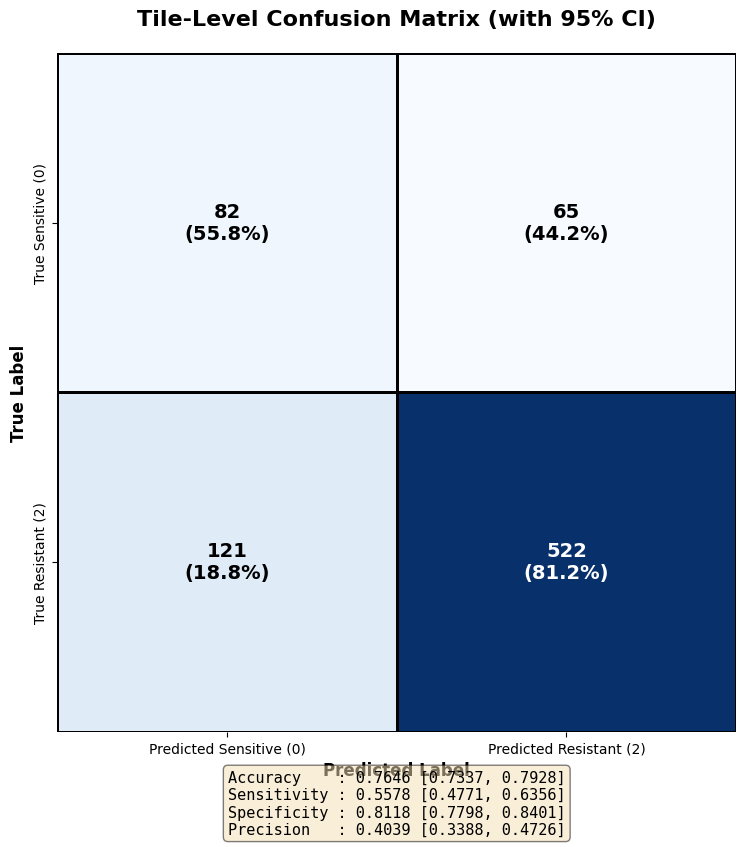

✓ Saved: /home/tatsushi/デスクトップ/sensitivity_data7/confusion_matrix_results/confusion_matrix_case.png


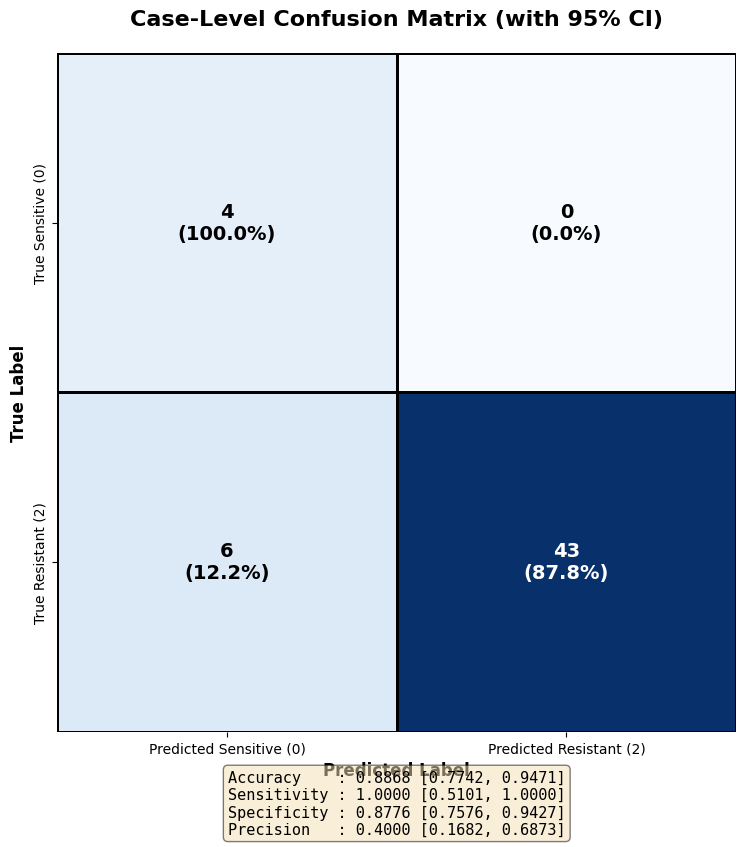

In [12]:
def plot_confusion_matrix(metrics, ci_dict, title, output_path, level='tile'):
    """混同行列をヒートマップで可視化し、値、割合、CIを注記"""
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    cm = metrics['confusion_matrix']
    
    # 正規化（割合）
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # ヒートマップ描画
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Sensitive (0)', 'Predicted Resistant (2)'],
                yticklabels=['True Sensitive (0)', 'True Resistant (2)'],
                ax=ax, square=True, linewidths=2, linecolor='black',
                cbar_kws={'label': 'Count'})
    
    # セル内に情報を注記
    for i in range(2):
        for j in range(2):
            count = cm[i, j]
            pct = cm_normalized[i, j]
            text = f'{count}\n({pct*100:.1f}%)'
            ax.text(j + 0.5, i + 0.5, text, ha='center', va='center',
                   color='white' if count > cm.max() / 2 else 'black',
                   fontsize=14, fontweight='bold')
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    
    # 指標情報をテキストボックスで追加
    metrics_text = (
        f"Accuracy    : {metrics['Accuracy']:.4f} "
        f"[{ci_dict['Accuracy']['lower']:.4f}, {ci_dict['Accuracy']['upper']:.4f}]\n"
        f"Sensitivity : {metrics['Sensitivity']:.4f} "
        f"[{ci_dict['Sensitivity']['lower']:.4f}, {ci_dict['Sensitivity']['upper']:.4f}]\n"
        f"Specificity : {metrics['Specificity']:.4f} "
        f"[{ci_dict['Specificity']['lower']:.4f}, {ci_dict['Specificity']['upper']:.4f}]\n"
        f"Precision   : {metrics['Precision']:.4f} "
        f"[{ci_dict['Precision']['lower']:.4f}, {ci_dict['Precision']['upper']:.4f}]"
    )
    
    fig.text(0.5, -0.05, metrics_text, ha='center', fontsize=11,
            family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {output_path}")
    plt.show()

# 出力フォルダを作成
output_dir = Path("/home/tatsushi/デスクトップ/sensitivity_data7/confusion_matrix_results")
output_dir.mkdir(parents=True, exist_ok=True)

# タイルレベルの混同行列を可視化・保存
plot_confusion_matrix(
    tile_metrics, tile_ci,
    'Tile-Level Confusion Matrix (with 95% CI)',
    output_dir / 'confusion_matrix_tile.png',
    level='tile'
)

# ケースレベルの混同行列を可視化・保存
plot_confusion_matrix(
    case_metrics, case_ci,
    'Case-Level Confusion Matrix (with 95% CI)',
    output_dir / 'confusion_matrix_case.png',
    level='case'
)

## 10. 結果を .xlsx に保存

In [13]:
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

# 新しいExcelワークブックを作成
wb = Workbook()
wb.remove(wb.active)  # デフォルトシートを削除

# ============================================================
# タイルレベルシート
# ============================================================
ws_tile = wb.create_sheet("Tile-Level")

# タイトルと説明
ws_tile['A1'] = "Tile-Level Confusion Matrix Analysis"
ws_tile['A1'].font = Font(size=14, bold=True)
ws_tile['A3'] = "Confusion Matrix:"
ws_tile['A3'].font = Font(size=12, bold=True)

# 混同行列を記載
cm_tile = tile_metrics['confusion_matrix']
ws_tile['A4'] = ""
ws_tile['B4'] = "Predicted Sensitive (0)"
ws_tile['C4'] = "Predicted Resistant (2)"
ws_tile['A5'] = "True Sensitive (0)"
ws_tile['B5'] = cm_tile[0, 0]  # TN
ws_tile['C5'] = cm_tile[0, 1]  # FP
ws_tile['A6'] = "True Resistant (2)"
ws_tile['B6'] = cm_tile[1, 0]  # FN
ws_tile['C6'] = cm_tile[1, 1]  # TP

# 指標と信頼区間
ws_tile['A9'] = "Metrics with 95% Confidence Intervals (Wilson Score):"
ws_tile['A9'].font = Font(size=12, bold=True)

row = 11
metrics_list = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision']
ws_tile['A' + str(row)] = "Metric"
ws_tile['B' + str(row)] = "Estimate"
ws_tile['C' + str(row)] = "Lower 95% CI"
ws_tile['D' + str(row)] = "Upper 95% CI"
ws_tile['E' + str(row)] = "N"

for col in ['A', 'B', 'C', 'D', 'E']:
    ws_tile[col + str(row)].font = Font(bold=True)
    ws_tile[col + str(row)].fill = PatternFill(start_color="D3D3D3", end_color="D3D3D3", fill_type="solid")

row += 1
for metric_name in metrics_list:
    ci_info = tile_ci[metric_name]
    ws_tile['A' + str(row)] = metric_name
    ws_tile['B' + str(row)] = ci_info['estimate']
    ws_tile['B' + str(row)].number_format = '0.0000'
    ws_tile['C' + str(row)] = ci_info['lower']
    ws_tile['C' + str(row)].number_format = '0.0000'
    ws_tile['D' + str(row)] = ci_info['upper']
    ws_tile['D' + str(row)].number_format = '0.0000'
    ws_tile['E' + str(row)] = ci_info['n']
    row += 1

# サンプル数
ws_tile['A' + str(row + 1)] = f"Total samples: {len(df_tiles)}"
ws_tile['A' + str(row + 2)] = f"Sensitive cases: {(df_tiles['true_label'] == 0).sum()}"
ws_tile['A' + str(row + 3)] = f"Resistant cases: {(df_tiles['true_label'] == 2).sum()}"

# ============================================================
# ケースレベルシート
# ============================================================
ws_case = wb.create_sheet("Case-Level")

# タイトルと説明
ws_case['A1'] = "Case-Level Confusion Matrix Analysis"
ws_case['A1'].font = Font(size=14, bold=True)
ws_case['A3'] = "Confusion Matrix:"
ws_case['A3'].font = Font(size=12, bold=True)

# 混同行列を記載
cm_case = case_metrics['confusion_matrix']
ws_case['A4'] = ""
ws_case['B4'] = "Predicted Sensitive (0)"
ws_case['C4'] = "Predicted Resistant (2)"
ws_case['A5'] = "True Sensitive (0)"
ws_case['B5'] = cm_case[0, 0]  # TN
ws_case['C5'] = cm_case[0, 1]  # FP
ws_case['A6'] = "True Resistant (2)"
ws_case['B6'] = cm_case[1, 0]  # FN
ws_case['C6'] = cm_case[1, 1]  # TP

# 指標と信頼区間
ws_case['A9'] = "Metrics with 95% Confidence Intervals (Wilson Score):"
ws_case['A9'].font = Font(size=12, bold=True)

row = 11
ws_case['A' + str(row)] = "Metric"
ws_case['B' + str(row)] = "Estimate"
ws_case['C' + str(row)] = "Lower 95% CI"
ws_case['D' + str(row)] = "Upper 95% CI"
ws_case['E' + str(row)] = "N"

for col in ['A', 'B', 'C', 'D', 'E']:
    ws_case[col + str(row)].font = Font(bold=True)
    ws_case[col + str(row)].fill = PatternFill(start_color="D3D3D3", end_color="D3D3D3", fill_type="solid")

row += 1
for metric_name in metrics_list:
    ci_info = case_ci[metric_name]
    ws_case['A' + str(row)] = metric_name
    ws_case['B' + str(row)] = ci_info['estimate']
    ws_case['B' + str(row)].number_format = '0.0000'
    ws_case['C' + str(row)] = ci_info['lower']
    ws_case['C' + str(row)].number_format = '0.0000'
    ws_case['D' + str(row)] = ci_info['upper']
    ws_case['D' + str(row)].number_format = '0.0000'
    ws_case['E' + str(row)] = ci_info['n']
    row += 1

# サンプル数
ws_case['A' + str(row + 1)] = f"Total cases: {len(df_cases)}"
ws_case['A' + str(row + 2)] = f"Sensitive cases: {(df_cases['true_label'] == 0).sum()}"
ws_case['A' + str(row + 3)] = f"Resistant cases: {(df_cases['true_label'] == 2).sum()}"

# ============================================================
# タイル詳細シート
# ============================================================
ws_tile_detail = wb.create_sheet("Tile Details")
for r_idx, row in enumerate(dataframe_to_rows(df_tiles[['case_id', 'true_class', 'final_class', 'final_prob', 'final_margin', 'vit_prob', 'eva_prob']], index=False, header=True), 1):
    for c_idx, value in enumerate(row, 1):
        ws_tile_detail.cell(row=r_idx, column=c_idx, value=value)

# ============================================================
# ケース詳細シート
# ============================================================
ws_case_detail = wb.create_sheet("Case Details")
for r_idx, row in enumerate(dataframe_to_rows(df_cases[['case_id', 'true_class', 'final_class', 'final_prob', 'final_margin', 'n_tiles']], index=False, header=True), 1):
    for c_idx, value in enumerate(row, 1):
        ws_case_detail.cell(row=r_idx, column=c_idx, value=value)

# 列幅を自動調整
for ws in [ws_tile, ws_case, ws_tile_detail, ws_case_detail]:
    for column in ws.columns:
        max_length = 0
        column_letter = column[0].column_letter
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = min(max_length + 2, 50)
        ws.column_dimensions[column_letter].width = adjusted_width

# ファイルを保存
excel_path = output_dir / 'confusion_matrix_results.xlsx'
wb.save(excel_path)
print(f"\n✓ Saved: {excel_path}")
print(f"  Sheets: Tile-Level, Case-Level, Tile Details, Case Details")


✓ Saved: /home/tatsushi/デスクトップ/sensitivity_data7/confusion_matrix_results/confusion_matrix_results.xlsx
  Sheets: Tile-Level, Case-Level, Tile Details, Case Details


## 11. 実行結果の確認とログ出力

In [68]:
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\n📁 Output Directory: {output_dir}")
print(f"\n📊 Generated Files:")
print(f"  ✓ confusion_matrix_tile.png")
print(f"  ✓ confusion_matrix_case.png")
print(f"  ✓ confusion_matrix_results.xlsx")

print(f"\n📈 Summary Statistics:")
print(f"\n  TILE-LEVEL (n={len(df_tiles)} images):")
print(f"    • Accuracy    : {tile_metrics['Accuracy']:.4f}")
print(f"    • Sensitivity : {tile_metrics['Sensitivity']:.4f}")
print(f"    • Specificity : {tile_metrics['Specificity']:.4f}")
print(f"    • Precision   : {tile_metrics['Precision']:.4f}")

print(f"\n  CASE-LEVEL (n={len(df_cases)} cases):")
print(f"    • Accuracy    : {case_metrics['Accuracy']:.4f}")
print(f"    • Sensitivity : {case_metrics['Sensitivity']:.4f}")
print(f"    • Specificity : {case_metrics['Specificity']:.4f}")
print(f"    • Precision   : {case_metrics['Precision']:.4f}")

print(f"\n✅ Analysis completed successfully!")


ANALYSIS COMPLETE

📁 Output Directory: /home/tatsushi/デスクトップ/sensitivity_data7/confusion_matrix_results

📊 Generated Files:
  ✓ confusion_matrix_tile.png
  ✓ confusion_matrix_case.png
  ✓ confusion_matrix_results.xlsx

📈 Summary Statistics:

  TILE-LEVEL (n=482 images):
    • Accuracy    : 0.9066
    • Sensitivity : 0.9291
    • Specificity : 0.8986
    • Precision   : 0.7662

  CASE-LEVEL (n=23 cases):
    • Accuracy    : 1.0000
    • Sensitivity : 1.0000
    • Specificity : 1.0000
    • Precision   : 1.0000

✅ Analysis completed successfully!


## 追加分析：詳細統計とエラー分析（オプション）

In [70]:
# 誤分類画像の詳細分析
print("\n" + "="*60)
print("MISCLASSIFICATION ANALYSIS")
print("="*60)

# タイルレベルでの誤分類
df_errors = df_tiles[df_tiles['true_label'] != df_tiles['final_label']].copy()

if len(df_errors) > 0:
    print(f"\n⚠ Total misclassified tiles: {len(df_errors)}")
    print(f"\nMisclassification breakdown:")
    
    # False Positives (True 0_sens, Pred 2_resis)
    fp_count = len(df_errors[df_errors['true_label'] == 0])
    print(f"  False Positives (Sens→Resis)  : {fp_count}")
    
    # False Negatives (True 2_resis, Pred 0_sens)
    fn_count = len(df_errors[df_errors['true_label'] == 2])
    print(f"  False Negatives (Resis→Sens)  : {fn_count}")
    
    # 誤分類画像の平均確度
    print(f"\nMisclassified tiles - average probabilities:")
    print(f"  ViT probability   : {df_errors['vit_prob'].mean():.4f}")
    print(f"  EVA02 probability : {df_errors['eva_prob'].mean():.4f}")
    print(f"  Final probability : {df_errors['final_prob'].mean():.4f}")
    
else:
    print("\n✓ No misclassified tiles!")

# ケースレベルでの誤分類
df_case_errors = df_cases[df_cases['true_label'] != df_cases['final_label']].copy()

if len(df_case_errors) > 0:
    print(f"\n⚠ Misclassified cases: {len(df_case_errors)}")
    print(f"\nMisclassified case details:")
    for idx, row in df_case_errors.iterrows():
        print(f"  • {row['case_id']}: True={row['true_class']}, Pred={row['final_class']}, "
              f"prob={row['final_prob']:.4f}, n_tiles={row['n_tiles']}")
else:
    print("\n✓ No misclassified cases!")

# モデル間の agreement 分析（タイルレベル）
print(f"\n" + "="*60)
print("MODEL AGREEMENT ANALYSIS (Tile-level)")
print("="*60)

vit_pred = df_tiles['vit_label'].values
eva_pred = df_tiles['eva_label'].values

agreement_count = np.sum(vit_pred == eva_pred)
disagreement_count = np.sum(vit_pred != eva_pred)

print(f"\nViT-EVA02 Agreement:")
print(f"  Agree      : {agreement_count} ({agreement_count/len(df_tiles)*100:.1f}%)")
print(f"  Disagree   : {disagreement_count} ({disagreement_count/len(df_tiles)*100:.1f}%)")

# Disagreement における正解率
disagreement_mask = vit_pred != eva_pred
if disagreement_count > 0:
    disagreement_correct = np.sum((df_tiles[disagreement_mask]['final_label'] == 
                                   df_tiles[disagreement_mask]['true_label']).values)
    print(f"\nWhen models disagree:")
    print(f"  Ensemble accuracy: {disagreement_correct/disagreement_count*100:.1f}%")


MISCLASSIFICATION ANALYSIS

⚠ Total misclassified tiles: 45

Misclassification breakdown:
  False Positives (Sens→Resis)  : 9
  False Negatives (Resis→Sens)  : 36

Misclassified tiles - average probabilities:
  ViT probability   : 0.6326
  EVA02 probability : 0.4923
  Final probability : 0.5624

✓ No misclassified cases!

MODEL AGREEMENT ANALYSIS (Tile-level)

ViT-EVA02 Agreement:
  Agree      : 403 (83.6%)
  Disagree   : 79 (16.4%)

When models disagree:
  Ensemble accuracy: 72.2%
